# NTU Lecture Hall Electricity — Data Loading & Cleaning

**Project:** Quantifying excess AC electricity from over-cooling in NTU lecture halls  
**Role:** Energy Data Consulting firm presenting to NTU  
**Data:** Hourly electricity meters for 普通, 共同, 博雅, 新生 lecture halls (2016–2025)

### Meters

| Variable | Meter | Type | Coverage |
|---|---|---|---|
| `df_ac` | 普通高壓空調 | AC only | 2016–2025, **ground truth for AC** |
| `df_putong1` | 普通教室用電新設一 | Total elec. sub-meter 1 | 2016–2025 |
| `df_putong2` | 普通教室用電新設二 | Total elec. sub-meter 2 | 2016–2025 |
| `df_elevator` | 普通教室電梯用電 | Elevator only | 2016–2025 |
| `df_gongtong` | 共同教室 | Total electricity | 2016–2025 |
| `df_boya1–4` | 博雅館一/二/三/四 | Total electricity | 2016–2025 |
| `df_xinsheng` | 新生大樓 | Total electricity | 2016–2025 |

> **Key insight:** Summing all 普通 sub-meters gives the **total electricity for 普通 lecture hall**, enabling decomposition validation — we can check that `AC_inferred = Total − Base_load` matches the actual AC meter.

## 0. Setup

In [ ]:
!pip install python-calamine beautifulsoup4 html5lib pandas numpy matplotlib seaborn scikit-learn xgboost shap lxml pyarrow

In [2]:
import platform
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import warnings
from pathlib import Path

# ---------------------------------------------------------------------------
# Cross-platform Chinese font setup
# Priority: (1) repo-bundled font  →  (2) OS system font  →  (3) fallback
# To ensure everyone gets the same font, place a .ttc/.ttf file in fonts/
# e.g. download NotoSansCJKtc-Regular.otf from Google Fonts and put it there.
# ---------------------------------------------------------------------------
def find_cjk_font() -> str:
    # 1. Repo-bundled fonts (works on all platforms after git clone)
    for repo_path in Path('fonts').glob('*.tt[cf]') if Path('fonts').exists() else []:
        fm.fontManager.addfont(str(repo_path))
        name = fm.FontProperties(fname=str(repo_path)).get_name()
        print(f'✓ Using repo font: {name}')
        return name

    # 2. OS-specific system fonts
    system = platform.system()
    candidates = {
        'Darwin': [                                       # macOS
            '/Library/Fonts/SourceHanSerif-SemiBold.ttc',
            '/Library/Fonts/SourceHanSans-Regular.ttc',
            '/System/Library/Fonts/STHeiti Medium.ttc',
            '/Library/Fonts/Arial Unicode.ttf',
        ],
        'Windows': [                                      # Windows
            r'C:\Windows\Fonts\msjh.ttc',                # 微軟正黑體 (Traditional Chinese)
            r'C:\Windows\Fonts\mingliu.ttc',             # 細明體
            r'C:\Windows\Fonts\kaiu.ttf',                # 標楷體
        ],
        'Linux': [                                        # Linux / Colab
            '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
            '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
        ],
    }.get(system, [])

    for path in candidates:
        if Path(path).exists():
            fm.fontManager.addfont(path)
            name = fm.FontProperties(fname=path).get_name()
            print(f'✓ Using system font: {name} ({path})')
            return name

    # 3. Search installed fonts for any CJK-capable font
    cjk_keywords = ['CJK', 'Chinese', 'Gothic', 'Heiti', 'Noto Sans CJK',
                     'Microsoft JhengHei', 'MingLiU', 'Source Han']
    for f in fm.fontManager.ttflist:
        if any(kw.lower() in f.name.lower() for kw in cjk_keywords):
            print(f'✓ Using installed font: {f.name}')
            return f.name

    print('⚠ No CJK font found — Chinese labels may show as boxes.')
    return 'sans-serif'

font_name = find_cjk_font()
plt.rcParams['font.family']        = font_name
plt.rcParams['font.weight']        = 'bold'
plt.rcParams['axes.titleweight']   = 'bold'
plt.rcParams['axes.labelweight']   = 'bold'
plt.rcParams['figure.titleweight'] = 'bold'
matplotlib.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_DIR = Path('data')
COLS = ['datetime', 'kw', 'meter_val', 'kwh', 'pf',
        'I_r', 'I_s', 'I_t', 'V_rs', 'V_st', 'V_tr', 'kva', 'kvar']

print(f'Platform : {platform.system()}')
print(f'Data dir : {DATA_DIR.exists()} ({len(list(DATA_DIR.glob("*.xls")))} XLS files)')

✓ Using system font: Source Han Serif (/Library/Fonts/SourceHanSerif-SemiBold.ttc)
Platform : Darwin
Data dir : True (88 XLS files)


## 1. File Loading Helpers

Two file formats exist in the data folder:
- **HTML-disguised XLS** (~7.5 MB): most files — use `pd.read_html` with Big5 encoding
- **True binary XLS** (~1.2 MB): 新生大樓 files — use `pd.read_excel` with `engine='calamine'`

In [3]:
def load_html_xls(path: Path) -> pd.DataFrame:
    """Load an HTML-disguised .xls file (most meters)."""
    tables = pd.read_html(path, encoding='big5')
    # Table 0 is a header block; table 1 has the data with row 0 as column names
    df = tables[1].iloc[1:].copy()
    df.columns = COLS
    return df


def load_binary_xls(path: Path) -> pd.DataFrame:
    """Load a true binary .xls file (新生大樓)."""
    df = pd.read_excel(path, engine='calamine', header=0)
    df = df.iloc[1:].copy()  # row 0 is column names in the sheet
    df.columns = COLS
    return df


def is_binary_xls(path: Path) -> bool:
    """Binary XLS files start with the OLE2 magic bytes d0cf11e0."""
    with open(path, 'rb') as f:
        return f.read(4) == b'\xd0\xcf\x11\xe0'


def load_xls(path: Path) -> pd.DataFrame:
    """Dispatch to the correct loader based on file format."""
    if is_binary_xls(path):
        return load_binary_xls(path)
    return load_html_xls(path)


def clean(df: pd.DataFrame, meter_name: str) -> pd.DataFrame:
    """
    Parse types, remove impossible values, add time features.
    Returns a clean DataFrame indexed by datetime.
    """
    df = df.copy()

    # --- parse types ---
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    for col in ['kw', 'kwh', 'pf', 'meter_val', 'kva', 'kvar',
                'I_r', 'I_s', 'I_t', 'V_rs', 'V_st', 'V_tr']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['datetime']).set_index('datetime').sort_index()

    # --- remove impossible readings ---
    n_before = len(df)
    df = df[df['kw'] >= 0]                        # no negative power
    df = df[df['kwh'] >= 0]                        # no negative energy
    df = df[df['kw'] < df['kw'].quantile(0.9999)]  # remove extreme spikes
    n_after = len(df)
    if n_before != n_after:
        print(f'  [{meter_name}] Removed {n_before - n_after} anomalous rows '
              f'({(n_before - n_after) / n_before * 100:.2f}%)')

    # --- detect & flag meter resets (sudden large drop in cumulative meter_val) ---
    df['meter_reset'] = df['meter_val'].diff() < -1000
    n_resets = df['meter_reset'].sum()
    if n_resets > 0:
        print(f'  [{meter_name}] Flagged {n_resets} potential meter reset(s)')

    # --- time features ---
    df['year']       = df.index.year
    df['month']      = df.index.month
    df['hour']       = df.index.hour
    df['weekday']    = df.index.weekday          # 0=Mon, 6=Sun
    df['is_weekend'] = df['weekday'] >= 5
    df['season']     = df['month'].map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring',  4: 'Spring', 5: 'Spring',
        6: 'Summer',  7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    })
    # NTU academic semesters: ~Sep–Jan (fall) and ~Feb–Jun (spring)
    df['is_semester'] = df['month'].isin([2, 3, 4, 5, 6, 9, 10, 11, 12])

    df['meter'] = meter_name
    return df


def load_meter(prefix: str, meter_name: str,
               years: range = range(2016, 2026)) -> pd.DataFrame:
    """
    Load and concatenate all annual files for a given meter prefix.
    Skips missing files with a warning.
    """
    frames = []
    for yr in years:
        path = DATA_DIR / f'{prefix}{yr}.xls'
        if not path.exists():
            print(f'  WARNING: {path.name} not found, skipping')
            continue
        frames.append(load_xls(path))

    if not frames:
        raise FileNotFoundError(f'No files found for prefix "{prefix}"')

    df = pd.concat(frames, ignore_index=True)
    return clean(df, meter_name)

## 2. Load 普通高壓空調 (AC sub-meter)

This is the only direct AC ground-truth. Files: individual 2016–2020 + one combined 2021–2025 file.

In [4]:
print('Loading 普通高壓空調 (AC meter)...')

# 2016–2020: individual files
ac_frames = []
for yr in range(2016, 2021):
    path = DATA_DIR / f'普通高壓空調{yr}.xls'
    ac_frames.append(load_xls(path))

# 2021–2025: single combined file
path_combined = DATA_DIR / '普通高壓空調2021-2025.xls'
ac_frames.append(load_xls(path_combined))

df_ac = pd.concat(ac_frames, ignore_index=True)
df_ac = clean(df_ac, '普通_AC')

# Remove the duplicate boundary row at 2021-01-01 00:00 from the overlap
df_ac = df_ac[~df_ac.index.duplicated(keep='first')]

print(f'\n普通 AC meter: {len(df_ac):,} hourly rows')
print(f'  Range: {df_ac.index.min()} → {df_ac.index.max()}')
print(f'  Avg power: {df_ac["kw"].mean():.1f} kW')
print(f'  Total energy: {df_ac["kwh"].sum():,.0f} kWh')
df_ac.head(3)

Loading 普通高壓空調 (AC meter)...
  [普通_AC] Removed 7922 anomalous rows (9.04%)
  [普通_AC] Flagged 2 potential meter reset(s)

普通 AC meter: 79,751 hourly rows
  Range: 2016-01-01 00:00:00 → 2026-01-01 00:00:00
  Avg power: 27.8 kW
  Total energy: 2,215,207 kWh


,kw,meter_val,kwh,pf,I_r,I_s,I_t,V_rs,V_st,V_tr,...,kvar,meter_reset,year,month,hour,weekday,is_weekend,season,is_semester,meter
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,5.74,405878.69,5.75,72.00,0.16,0.20,0.29,23859.09,24069.51,24066.03,...,-5.50,False,2016,1,0,4,False,Winter,False,普通_AC
2016-01-01 01:00:00,5.91,405884.44,6.00,73.00,0.16,0.21,0.30,23904.95,24119.71,24103.92,...,-5.41,False,2016,1,1,4,False,Winter,False,普通_AC
2016-01-01 02:00:00,6.16,405890.44,6.34,76.00,0.17,0.21,0.30,24047.02,24199.70,24170.29,...,-5.23,False,2016,1,2,4,False,Winter,False,普通_AC


## 2b. Load Other 普通 Sub-meters (新設一, 新設二, 電梯)

These give us total electricity for 普通 when summed with the AC meter.  
This enables **decomposition validation** in Stage 4.

In [5]:
print('Loading 普通教室用電新設一 (two combined files)...')
putong1_frames = []
for fpath in [DATA_DIR / '普通教室用電新設一2016-2020.xls',
              DATA_DIR / '普通教室用電新設一2021-2026.xls']:
    putong1_frames.append(load_xls(fpath))
df_putong1 = pd.concat(putong1_frames, ignore_index=True)
df_putong1 = clean(df_putong1, '普通新設一')
df_putong1 = df_putong1[~df_putong1.index.duplicated(keep='first')]
print(f'  {len(df_putong1):,} rows | {df_putong1.index.min().date()} → {df_putong1.index.max().date()}')
print(f'  Avg power: {df_putong1["kw"].mean():.1f} kW | Total: {df_putong1["kwh"].sum():,.0f} kWh')

print('\nLoading 普通教室用電新設二 (annual files)...')
df_putong2 = load_meter('普通教室用電新設二', '普通新設二')
print(f'  {len(df_putong2):,} rows | {df_putong2.index.min().date()} → {df_putong2.index.max().date()}')
print(f'  Avg power: {df_putong2["kw"].mean():.1f} kW | Total: {df_putong2["kwh"].sum():,.0f} kWh')

print('\nLoading 普通教室電梯用電 (annual files)...')
df_elevator = load_meter('普通教室電梯用電', '普通電梯')
print(f'  {len(df_elevator):,} rows | {df_elevator.index.min().date()} → {df_elevator.index.max().date()}')
print(f'  Avg power: {df_elevator["kw"].mean():.1f} kW | Total: {df_elevator["kwh"].sum():,.0f} kWh')

Loading 普通教室用電新設一 (two combined files)...
  [普通新設一] Removed 954 anomalous rows (1.09%)
  [普通新設一] Flagged 1 potential meter reset(s)
  86,719 rows | 2016-01-01 → 2026-01-01
  Avg power: 13.3 kW | Total: 1,160,588 kWh

Loading 普通教室用電新設二 (annual files)...
  [普通新設二] Removed 934 anomalous rows (1.07%)
  86,748 rows | 2016-01-01 → 2026-01-01
  Avg power: 0.4 kW | Total: 32,902 kWh

Loading 普通教室電梯用電 (annual files)...
  [普通電梯] Removed 979 anomalous rows (1.12%)
  86,703 rows | 2016-01-01 → 2026-01-01
  Avg power: 0.2 kW | Total: 19,837 kWh


## 3. Load Lecture Hall Total Electricity Meters

In [6]:
print('Loading 共同教室...')
df_gongtong = load_meter('共同教室', '共同教室')
print(f'  {len(df_gongtong):,} rows | {df_gongtong.index.min().date()} → {df_gongtong.index.max().date()}')
print(f'  Avg power: {df_gongtong["kw"].mean():.1f} kW | Total: {df_gongtong["kwh"].sum():,.0f} kWh')

Loading 共同教室...
  [共同教室] Removed 2328 anomalous rows (2.66%)
  [共同教室] Flagged 5 potential meter reset(s)
  85,354 rows | 2016-01-01 → 2026-01-01
  Avg power: 44.7 kW | Total: 3,813,403 kWh


In [7]:
print('Loading 博雅 sub-meters (館一, 館二, 三, 四)...')
df_boya1 = load_meter('博雅館一', '博雅館一')
df_boya2 = load_meter('博雅館二', '博雅館二')
df_boya3 = load_meter('博雅三',   '博雅三')
df_boya4 = load_meter('博雅四',   '博雅四')

# Combine all 博雅 sub-meters into one aggregated series
# Align on datetime index, sum kW and kWh
boya_kw  = (df_boya1['kw'].rename('b1') + df_boya2['kw'].rename('b2') +
            df_boya3['kw'].rename('b3') + df_boya4['kw'].rename('b4'))
boya_kwh = (df_boya1['kwh'].rename('b1') + df_boya2['kwh'].rename('b2') +
            df_boya3['kwh'].rename('b3') + df_boya4['kwh'].rename('b4'))

# Keep individual sub-meters for detailed analysis; also expose aggregated
df_boya_all = pd.concat([df_boya1, df_boya2, df_boya3, df_boya4])

for name, df in [('博雅館一', df_boya1), ('博雅館二', df_boya2),
                 ('博雅三',   df_boya3), ('博雅四',   df_boya4)]:
    print(f'  {name}: {len(df):,} rows | avg {df["kw"].mean():.1f} kW | total {df["kwh"].sum():,.0f} kWh')

Loading 博雅 sub-meters (館一, 館二, 三, 四)...
  [博雅館一] Removed 1461 anomalous rows (1.67%)
  [博雅館一] Flagged 5 potential meter reset(s)
  [博雅館二] Removed 1602 anomalous rows (1.83%)
  [博雅館二] Flagged 1 potential meter reset(s)
  [博雅三] Removed 1837 anomalous rows (2.10%)
  [博雅四] Removed 2101 anomalous rows (2.40%)
  [博雅四] Flagged 4 potential meter reset(s)
  博雅館一: 86,221 rows | avg 56.6 kW | total 5,133,276 kWh
  博雅館二: 86,080 rows | avg 12.2 kW | total 1,104,250 kWh
  博雅三: 85,845 rows | avg 5.5 kW | total 492,821 kWh
  博雅四: 85,581 rows | avg 39.6 kW | total 3,493,421 kWh


In [ ]:
print('Loading 新生大樓 (binary XLS — true OLE2 format)...')
df_xinsheng = load_meter('新生大樓', '新生大樓')
print(f'  {len(df_xinsheng):,} rows | {df_xinsheng.index.min().date()} → {df_xinsheng.index.max().date()}')
print(f'  Avg power: {df_xinsheng["kw"].mean():.1f} kW | Total: {df_xinsheng["kwh"].sum():,.0f} kWh')

## 4. Coverage Summary

## 5. Missing Timestamp Check & Gap Filling

In [ ]:
def fill_gaps(df: pd.DataFrame, meter_name: str,
              max_interp_hours: int = 3) -> pd.DataFrame:
    """
    Reindex to a complete hourly DatetimeIndex.
    Gaps <= max_interp_hours are linearly interpolated.
    Longer gaps are left as NaN and flagged.
    """
    # Drop duplicate timestamps before reindexing (e.g. from DST overlaps)
    n_dupes = df.index.duplicated().sum()
    if n_dupes > 0:
        print(f'  [{meter_name}] Dropping {n_dupes} duplicate timestamps')
        df = df[~df.index.duplicated(keep='first')]

    full_idx = pd.date_range(df.index.min(), df.index.max(), freq='h')
    df = df.reindex(full_idx)

    # Mark which rows were originally missing
    df['gap_filled'] = df['kw'].isna()

    # Interpolate only short gaps
    numeric_cols = ['kw', 'kwh', 'pf', 'kva', 'kvar']
    df[numeric_cols] = (
        df[numeric_cols]
        .interpolate(method='linear', limit=max_interp_hours)
    )

    long_gaps = df['kw'].isna().sum()
    filled    = df['gap_filled'].sum() - long_gaps
    print(f'  [{meter_name}] Interpolated {filled} short gaps; '
          f'{long_gaps} long gaps remain as NaN')

    # Re-derive time features for newly inserted rows
    df['year']       = df.index.year
    df['month']      = df.index.month
    df['hour']       = df.index.hour
    df['weekday']    = df.index.weekday
    df['is_weekend'] = df['weekday'] >= 5
    df['season']     = df['month'].map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring',  4: 'Spring', 5: 'Spring',
        6: 'Summer',  7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    })
    df['is_semester'] = df['month'].isin([2, 3, 4, 5, 6, 9, 10, 11, 12])
    df['meter']       = meter_name
    return df


print('Filling gaps (interpolating short gaps ≤ 3 hours)...')
df_ac        = fill_gaps(df_ac,        '普通_AC')
df_putong1   = fill_gaps(df_putong1,   '普通新設一')
df_putong2   = fill_gaps(df_putong2,   '普通新設二')
df_elevator  = fill_gaps(df_elevator,  '普通電梯')
df_gongtong  = fill_gaps(df_gongtong,  '共同教室')
df_boya1     = fill_gaps(df_boya1,     '博雅館一')
df_boya2     = fill_gaps(df_boya2,     '博雅館二')
df_boya3     = fill_gaps(df_boya3,     '博雅三')
df_boya4     = fill_gaps(df_boya4,     '博雅四')
df_xinsheng  = fill_gaps(df_xinsheng,  '新生大樓')

# Aggregate all 普通 sub-meters → total electricity for 普通 lecture hall
# Align on common index (inner join to avoid NaN from coverage gaps)
df_putong_total = (
    df_ac[['kw', 'kwh']].add(df_putong1[['kw', 'kwh']], fill_value=0)
                         .add(df_putong2[['kw', 'kwh']], fill_value=0)
                         .add(df_elevator[['kw', 'kwh']], fill_value=0)
)
df_putong_total.columns = ['kw_total', 'kwh_total']
print(f'\n普通 total (AC + 新設一 + 新設二 + 電梯): {len(df_putong_total):,} rows')

## 6. Quick Validation Plots

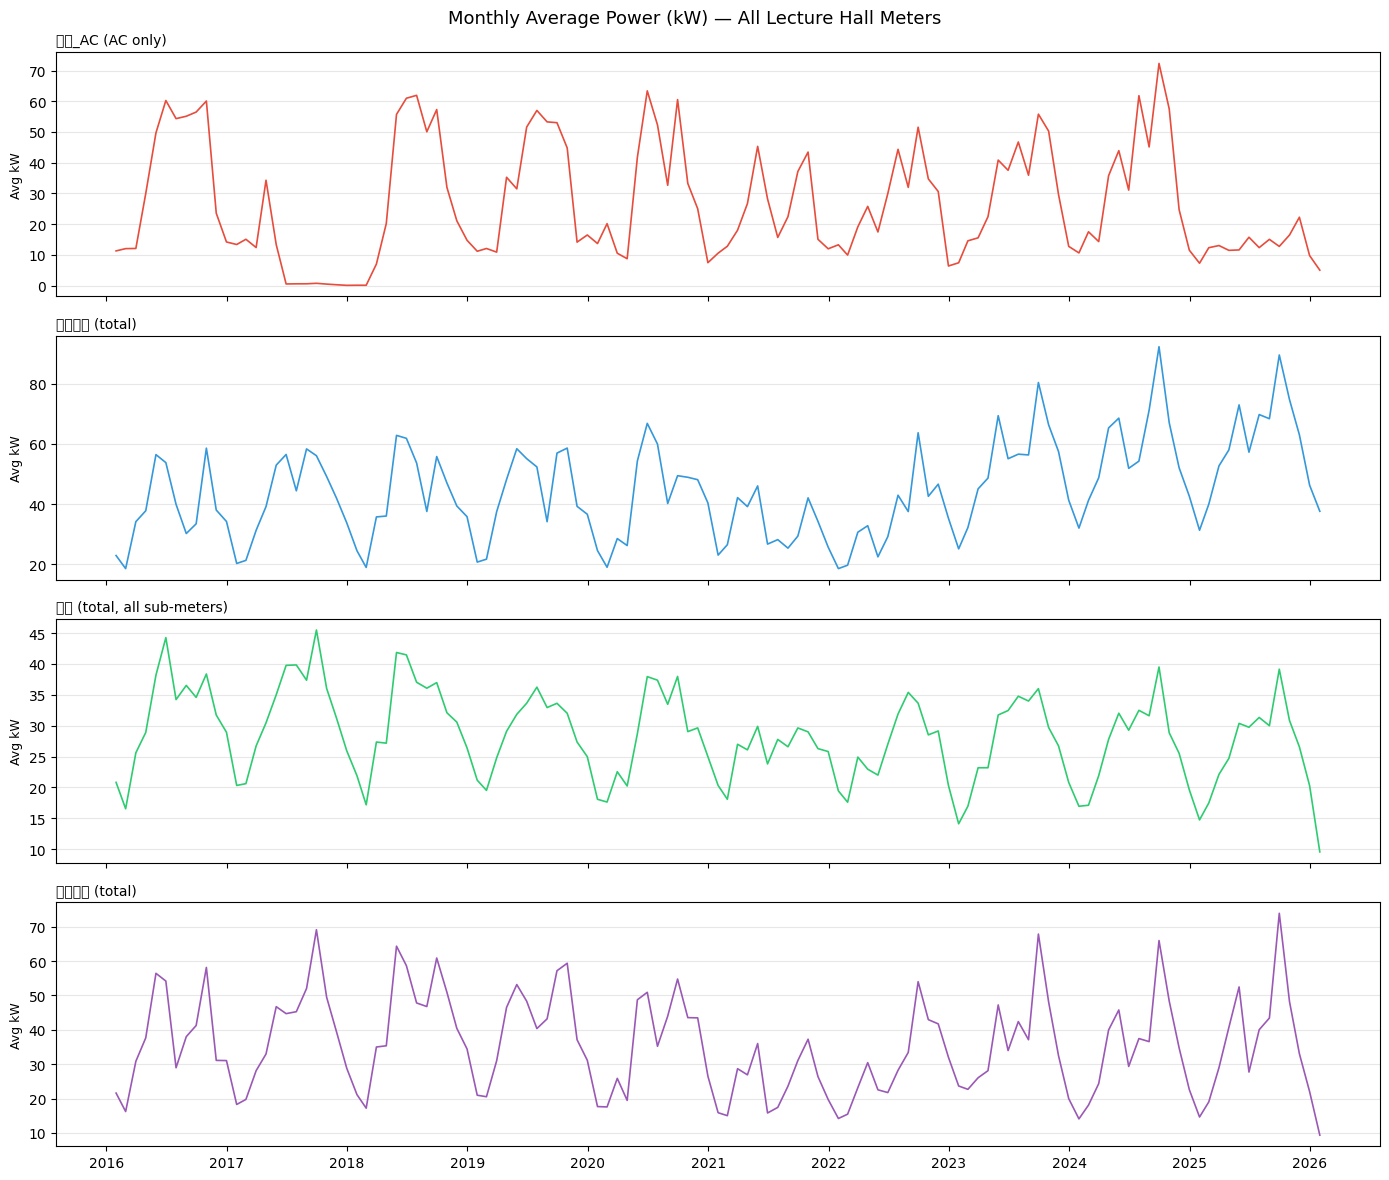

Plot saved to monthly_avg_power.png


In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Monthly Average Power (kW) — All Lecture Hall Meters', fontsize=13)

plot_data = [
    ('普通_AC (AC only)', df_ac,       '#e74c3c'),
    ('共同教室 (total)', df_gongtong,  '#3498db'),
    ('博雅 (total, all sub-meters)', df_boya_all, '#2ecc71'),
    ('新生大樓 (total)', df_xinsheng,  '#9b59b6'),
]

for ax, (label, df, color) in zip(axes, plot_data):
    monthly = df['kw'].resample('ME').mean()
    ax.plot(monthly.index, monthly.values, color=color, linewidth=1.2)
    ax.set_ylabel('Avg kW', fontsize=9)
    ax.set_title(label, fontsize=10, loc='left')
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('monthly_avg_power.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to monthly_avg_power.png')

In [ ]:
import os
os.makedirs('cleaned', exist_ok=True)

export_map = {
    'cleaned/ac_普通.parquet':           df_ac,
    'cleaned/putong1_普通新設一.parquet': df_putong1,
    'cleaned/putong2_普通新設二.parquet': df_putong2,
    'cleaned/elevator_普通電梯.parquet':  df_elevator,
    'cleaned/gongtong_共同教室.parquet':  df_gongtong,
    'cleaned/boya1_博雅館一.parquet':     df_boya1,
    'cleaned/boya2_博雅館二.parquet':     df_boya2,
    'cleaned/boya3_博雅三.parquet':       df_boya3,
    'cleaned/boya4_博雅四.parquet':       df_boya4,
    'cleaned/xinsheng_新生大樓.parquet':  df_xinsheng,
}

for fpath, df in export_map.items():
    df_out = df.select_dtypes(exclude='object').copy()
    df_out['meter'] = df['meter'].astype('category')
    df_out.to_parquet(fpath)
    print(f'Saved {fpath}  ({os.path.getsize(fpath) / 1024:.0f} KB)')

print('\nAll cleaned data exported to cleaned/')

## 7. Export Cleaned Data

Save cleaned DataFrames as Parquet for fast loading in subsequent notebooks.

## 8. Data Quality Report

## 9. 時間-用電量相似度

因為part 6的圖 2-4 看起來時間-用電量有類似變化趨勢，所以想看教學館間的用電量變化相關係數有多大，不過結果看起來沒有到很高。
原本想說如果相關係數高，可能代表不同教學館的用電比例差不多(?)，只是大小差異(有點像幾乎等比例放大)。
另外，part 6的圖 2-4 每一年都長得像 M 字形，應該是寒暑假跟氣溫的緣故。

In [ ]:
# 1: df_gongtong, 2: df_boya_all, 3: df_xinsheng
corr12 = df_gongtong['kwh'].corr(df_boya_all['kwh'])
corr13 = df_gongtong['kwh'].corr(df_xinsheng['kwh'])
corr23 = df_boya_all['kwh'].corr(df_xinsheng['kwh'])

print(corr12, corr13, corr23)

0.481657920172869 0.7898587844852659 0.4858742405478257


In [ ]:
# 0: df_ac, 1: df_gongtong, 2: df_boya_all, 3: df_xinsheng
corr01 = df_ac['kwh'].corr(df_gongtong['kwh'])
corr02 = df_ac['kwh'].corr(df_boya_all['kwh'])
corr03 = df_ac['kwh'].corr(df_xinsheng['kwh'])

print(corr01, corr02, corr03)

0.58087603449093 0.3597428416283034 0.6212605239773331
